In [1]:
# %%
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


In [2]:
# %%
# Initialize dictionary to collect results for genetic models.
# Here we include the original "only_genetics" model.
all_results = defaultdict(list)
base_path = "/n/data2/hms/dbmi/kyu/lab/chb3333/gem-patho/models/actual_final_results"

# Loop over the "only_genetics" model for the given batches and experiments.
for gen_image in ['genetics_and_image', 'only_genetics', "only_image"]:
    for batch in ['all_batch']:
        for exp in ['cancertypebatching_exp_0_phase2_10', 
                    'cancertypebatching_exp_1_phase2_0']:
            path = f"{base_path}/{gen_image}/{batch}/{exp}/global_test_cindices.csv"
            try:
                data = pd.read_csv(path)
                for cancer, c_idx in zip(data['cancer_type'], data['c_index']):
                    all_results['gen_image'].append(gen_image)
                    all_results['batch'].append(batch)
                    all_results['exp'].append(exp)
                    all_results['cancer'].append(cancer)
                    all_results['c_index'].append(c_idx)
            except Exception as e:
                # Skip missing or problematic files.
                print(f"Skipping file {path} due to error: {e}")


In [19]:
# %%
# Create a DataFrame from the collected results.
df = pd.DataFrame(all_results)
print("Raw Data:")
print(df.head())

# Group by model identifiers and calculate the average c-index and its standard error.
grouped = df.groupby(['gen_image', 'batch', 'exp'])['c_index'].agg(['mean', 'sem']).reset_index()
grouped.rename(columns={'mean': 'avg_c_index', 'sem': 'se_c_index'}, inplace=True)

# Create a column that uniquely identifies each model.
grouped["model"] = grouped["gen_image"] + "_" + grouped["batch"] + "_" + grouped["exp"]

# Compute the 95% confidence interval (CI = 1.96 * standard error).
grouped["ci95"] = 1.96 * grouped["se_c_index"]

print("Grouped Data:")
print(grouped)


Raw Data:
            gen_image      batch                                 exp  cancer  \
0  genetics_and_image  all_batch  cancertypebatching_exp_0_phase2_10       8   
1  genetics_and_image  all_batch  cancertypebatching_exp_0_phase2_10       2   
2  genetics_and_image  all_batch  cancertypebatching_exp_0_phase2_10      10   
3  genetics_and_image  all_batch  cancertypebatching_exp_0_phase2_10      12   
4  genetics_and_image  all_batch  cancertypebatching_exp_0_phase2_10      11   

    c_index  
0  0.501033  
1  0.532815  
2  0.486309  
3  0.585014  
4  0.554278  
Grouped Data:
            gen_image      batch                                 exp  \
0  genetics_and_image  all_batch  cancertypebatching_exp_0_phase2_10   
1  genetics_and_image  all_batch   cancertypebatching_exp_1_phase2_0   
2       only_genetics  all_batch  cancertypebatching_exp_0_phase2_10   
3       only_genetics  all_batch   cancertypebatching_exp_1_phase2_0   
4          only_image  all_batch  cancertypebatchin

In [20]:
grouped.iloc[[0, 2]] = grouped.iloc[[2, 0]].values
grouped.iloc[[1, 3]] = grouped.iloc[[3, 1]].values

grouped.iloc[[2, 4]] = grouped.iloc[[4, 2]].values
grouped.iloc[[3, 5]] = grouped.iloc[[5, 3]].values


In [21]:
# %%
# Assign sequential model numbers to each aggregated group.
grouped["model_number"] = range(1, len(grouped) + 1)
print("Model Numbers:")
print(grouped[['model_number', 'model']])


Model Numbers:
   model_number                                              model
0             1  only_genetics_all_batch_cancertypebatching_exp...
1             2  only_genetics_all_batch_cancertypebatching_exp...
2             3  only_image_all_batch_cancertypebatching_exp_0_...
3             4  only_image_all_batch_cancertypebatching_exp_1_...
4             5  genetics_and_image_all_batch_cancertypebatchin...
5             6  genetics_and_image_all_batch_cancertypebatchin...


In [22]:
# %%
# Define model label mapping.
# For the two only_genetics experiments we assign different names,
# and assign names for one_hot and ct_specific groups.
model_labels = {
    "PhasedCTBatchModel": "Phased CT-Batch Model",  # for exp "cancertypebatching_exp_0_phase2_10"
    "UniformBatchModel": "Uniform Batch Model"      # for exp "cancertypebatching_exp_1_phase2_0"
}

# Function to generate the label based on the "model" string.
def get_model_label(model_str):
    if "cancertypebatching_exp_0_phase2_10" in model_str:
         return model_labels["PhasedCTBatchModel"]
    elif "cancertypebatching_exp_1_phase2_0" in model_str:
         return model_labels["UniformBatchModel"]
    else:
         return model_str

# Apply the label mapping.
grouped["model_label"] = grouped["model"].apply(get_model_label)





In [23]:
grouped["model_label"]

0    Phased CT-Batch Model
1      Uniform Batch Model
2    Phased CT-Batch Model
3      Uniform Batch Model
4    Phased CT-Batch Model
5      Uniform Batch Model
Name: model_label, dtype: object

In [24]:
grouped

,gen_image,batch,exp,avg_c_index,se_c_index,model,ci95,model_number,model_label
0,only_genetics,all_batch,cancertypebatching_exp_0_phase2_10,0.520306,0.012892,only_genetics_all_batch_cancertypebatching_exp...,0.025268,1,Phased CT-Batch Model
1,only_genetics,all_batch,cancertypebatching_exp_1_phase2_0,0.529688,0.017125,only_genetics_all_batch_cancertypebatching_exp...,0.033565,2,Uniform Batch Model
2,only_image,all_batch,cancertypebatching_exp_0_phase2_10,0.567504,0.009536,only_image_all_batch_cancertypebatching_exp_0_...,0.018691,3,Phased CT-Batch Model
3,only_image,all_batch,cancertypebatching_exp_1_phase2_0,0.570331,0.009507,only_image_all_batch_cancertypebatching_exp_1_...,0.018634,4,Uniform Batch Model
4,genetics_and_image,all_batch,cancertypebatching_exp_0_phase2_10,0.565273,0.009402,genetics_and_image_all_batch_cancertypebatchin...,0.018429,5,Phased CT-Batch Model
5,genetics_and_image,all_batch,cancertypebatching_exp_1_phase2_0,0.568114,0.011121,genetics_and_image_all_batch_cancertypebatchin...,0.021797,6,Uniform Batch Model


In [25]:
# %%
# Replace the color_map with:
color_map = {
    "only_genetics": "tab:green",
    "only_image": "tab:orange",  # Your new purple
    "genetics_and_image": "tab:blue"
}
# Function to determine the color based on the model's key.
def get_color(model_str):
    if model_str.startswith("only_genetics"):
        return color_map["only_genetics"]
    elif model_str.startswith("only_image"):
        return color_map["only_image"]
    elif model_str.startswith("genetics_and_image"):
        return color_map["genetics_and_image"]
    else:
        return "tab:gray"

# Map each model to its assigned color.
colors = grouped["model"].apply(get_color)


def get_model_class(row):
    model_str = row["model"]
    model_label = row["model_label"]
    
    if model_str.startswith("only_genetics"):
        return "Genetics: " + model_label
    elif model_str.startswith("only_image"):
        return "Image: " + model_label
    elif model_str.startswith("genetics_and_image"):
        return "Multimodal: " + model_label

grouped["model_label_complete"] = grouped.apply(get_model_class, axis=1)



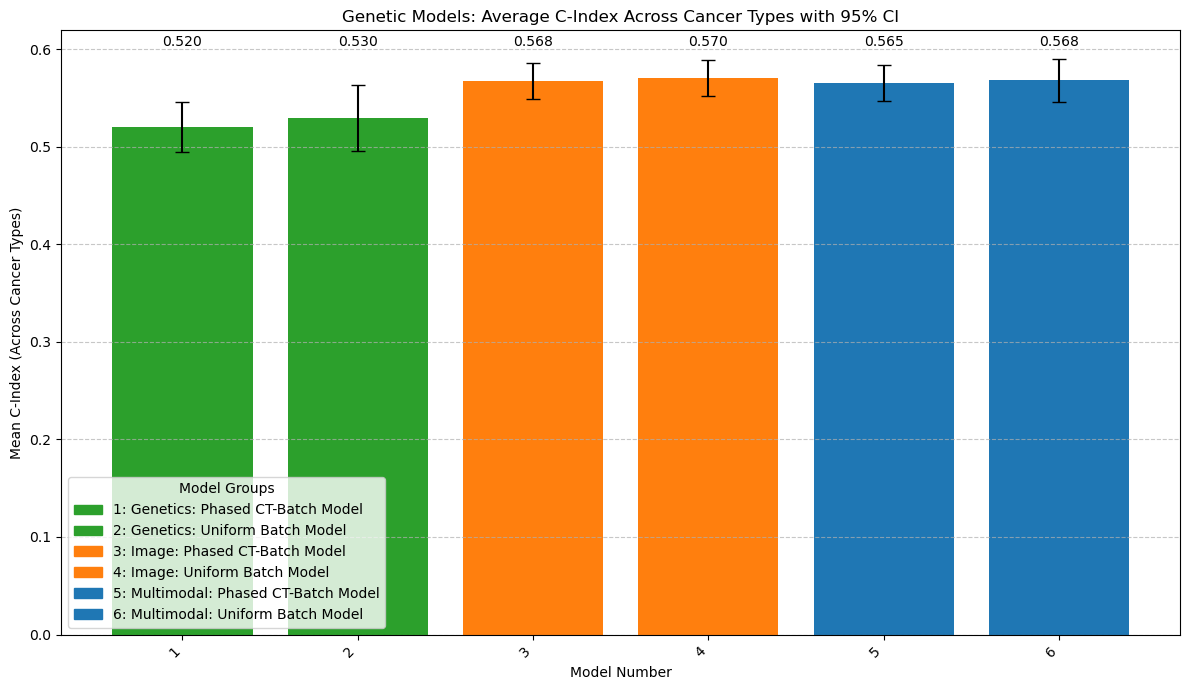

In [26]:
# %%
# Create the final bar plot.
plt.figure(figsize=(12, 7))
bars = plt.bar(range(len(grouped)), grouped["avg_c_index"],
               yerr=grouped["ci95"], capsize=5, color=colors)

# Keep numbers at the bottom.
plt.xticks(range(len(grouped)), grouped["model_number"], rotation=45, ha='right')
plt.ylabel("Mean C-Index (Across Cancer Types)")
plt.xlabel("Model Number")
plt.title("Genetic Models: Average C-Index Across Cancer Types with 95% CI")
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add numerical labels atop each bar.
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, 0.60, f'{height:.3f}', ha='center', va='bottom', fontsize=10)


# Build a custom legend.
# Build a custom legend that includes model numbers and labels.
legend_patches = []
for _, row in grouped.iterrows():
    legend_label = f"{row['model_number']}: {row['model_label_complete']}"
    legend_patches.append(mpatches.Patch(color=get_color(row['model']), label=legend_label))
plt.legend(handles=legend_patches, title="Model Groups")

plt.show()


In [27]:
grouped

,gen_image,batch,exp,avg_c_index,se_c_index,model,ci95,model_number,model_label,model_label_complete
0,only_genetics,all_batch,cancertypebatching_exp_0_phase2_10,0.520306,0.012892,only_genetics_all_batch_cancertypebatching_exp...,0.025268,1,Phased CT-Batch Model,Genetics: Phased CT-Batch Model
1,only_genetics,all_batch,cancertypebatching_exp_1_phase2_0,0.529688,0.017125,only_genetics_all_batch_cancertypebatching_exp...,0.033565,2,Uniform Batch Model,Genetics: Uniform Batch Model
2,only_image,all_batch,cancertypebatching_exp_0_phase2_10,0.567504,0.009536,only_image_all_batch_cancertypebatching_exp_0_...,0.018691,3,Phased CT-Batch Model,Image: Phased CT-Batch Model
3,only_image,all_batch,cancertypebatching_exp_1_phase2_0,0.570331,0.009507,only_image_all_batch_cancertypebatching_exp_1_...,0.018634,4,Uniform Batch Model,Image: Uniform Batch Model
4,genetics_and_image,all_batch,cancertypebatching_exp_0_phase2_10,0.565273,0.009402,genetics_and_image_all_batch_cancertypebatchin...,0.018429,5,Phased CT-Batch Model,Multimodal: Phased CT-Batch Model
5,genetics_and_image,all_batch,cancertypebatching_exp_1_phase2_0,0.568114,0.011121,genetics_and_image_all_batch_cancertypebatchin...,0.021797,6,Uniform Batch Model,Multimodal: Uniform Batch Model


METRICS CALCULATION

In [28]:
cancer_mapping = {
    'ACC': 0, 'BLCA': 1, 'BRCA': 2, 'CESC': 3, 'CHOL': 4, 'CNTL': 5,
    'COAD': 6, 'DLBC': 7, 'ESCA': 8, 'FPPP': 9, 'GBM': 10, 'HNSC': 11,
    'KICH': 12, 'KIRC': 13, 'KIRP': 14, 'LAML': 15, 'LCML': 16, 'LGG': 17,
    'LIHC': 18, 'LUAD': 19, 'LUSC': 20, 'MESO': 21, 'MISC': 22, 'OV': 23,
    'PAAD': 24, 'PCPG': 25, 'PRAD': 26, 'READ': 27, 'SARC': 28, 'SKCM': 29,
    'STAD': 30, 'TGCT': 31, 'THCA': 32, 'THYM': 33, 'UCEC': 34, 'UCS': 35,
    'UVM': 36
}

inv_mapping = {v: k for k, v in cancer_mapping.items()}

In [29]:
import pandas as pd
import numpy as np

# Replace with your actual file path
file_path = '/home/chb3333/yulab/chb3333/gem-patho/models/actual_final_results/only_image/all_batch/cancertypebatching_exp_0_phase2_10/global_test_cindices.csv'

# Load the CSV file
df = pd.read_csv(file_path)

# Calculate the average of the 'c_index' column
mean_c_index = df['c_index'].mean()
print("Average c_index:", mean_c_index)

# Make a copy to avoid SettingWithCopyWarning
filtered_df = df[df['c_index'] > 0.55].copy()

# Count how many rows have a c_index above 0.55
count_over = len(filtered_df)

# Calculate the average of the c_index values for those rows
average_over = filtered_df['c_index'].mean()

print("Count of c_index values over 0.55:", count_over)
print("Average c_index for values over 0.55:", average_over)

# Select the top 5 c_index values
top5 = df['c_index'].nlargest(5)

# Calculate mean and standard deviation
top5_avg = top5.mean()
top5_std = top5.std(ddof=1)  # sample std dev

# Compute standard error
top5_se = top5_std / np.sqrt(len(top5))

# Compute 95% confidence interval using normal approximation (1.96 * SE)
top5_ci95 = 1.96 * top5_se

print("Average of top 5 c_index values:", top5_avg)
print("Standard deviation of top 5 c_index values:", top5_std)
print("Standard error:", top5_se)
print(f"95% CI: [{top5_avg - top5_ci95:.4f}, {top5_avg + top5_ci95:.4f}]")

# Replace cancer_type using inverse mapping
filtered_df['cancer_type'] = filtered_df['cancer_type'].map(inv_mapping)

print("\nRows with c_index > 0.55:")
print(filtered_df)


Average c_index: 0.5675039393356164
Count of c_index values over 0.55: 19
Average c_index for values over 0.55: 0.6024102546565123
Average of top 5 c_index values: 0.6584739771011484
Standard deviation of top 5 c_index values: 0.012720653317752968
Standard error: 0.005688849107340774
95% CI: [0.6473, 0.6696]

Rows with c_index > 0.55:
   cancer_type   c_index
1         BRCA  0.619910
3         KICH  0.630045
5          LGG  0.649972
7         KIRC  0.649021
10        COAD  0.556538
11        DLBC  0.638298
13        CHOL  0.561873
14        BLCA  0.552979
15         ACC  0.680238
16        MESO  0.565997
17        LIHC  0.567109
20        KIRP  0.553109
21        PRAD  0.658098
22        SARC  0.593123
23        READ  0.569223
27        THCA  0.577451
29        TGCT  0.604106
30        PAAD  0.563665
32        UCEC  0.655041


In [30]:
# Replace with your actual file path
file_path = '/home/chb3333/yulab/chb3333/gem-patho/models/actual_final_results/only_image/all_batch/cancertypebatching_exp_1_phase2_0/global_test_cindices.csv'

# Load the CSV file
df = pd.read_csv(file_path)

# Calculate the average of the 'c_index' column
mean_c_index = df['c_index'].mean()
print("Average c_index:", mean_c_index)

# Make a copy to avoid SettingWithCopyWarning
filtered_df = df[df['c_index'] > 0.55].copy()

# Count how many rows have a c_index above 0.55
count_over = len(filtered_df)

# Calculate the average of the c_index values for those rows
average_over = filtered_df['c_index'].mean()

print("Count of c_index values over 0.55:", count_over)
print("Average c_index for values over 0.55:", average_over)

# Select the top 5 c_index values
top5 = df['c_index'].nlargest(5)

# Calculate mean and standard deviation
top5_avg = top5.mean()
top5_std = top5.std(ddof=1)  # sample std dev

# Compute standard error
top5_se = top5_std / np.sqrt(len(top5))

# Compute 95% confidence interval using normal approximation (1.96 * SE)
top5_ci95 = 1.96 * top5_se

print("Average of top 5 c_index values:", top5_avg)
print("Standard deviation of top 5 c_index values:", top5_std)
print("Standard error:", top5_se)
print(f"95% CI: [{top5_avg - top5_ci95:.4f}, {top5_avg + top5_ci95:.4f}]")

# Replace cancer_type using inverse mapping
filtered_df['cancer_type'] = filtered_df['cancer_type'].map(inv_mapping)

print("\nRows with c_index > 0.55:")
print(filtered_df)

Average c_index: 0.5703310711990098
Count of c_index values over 0.55: 20
Average c_index for values over 0.55: 0.6027030572032308
Average of top 5 c_index values: 0.6606791418619398
Standard deviation of top 5 c_index values: 0.02680536210500032
Standard error: 0.011987722365655514
95% CI: [0.6372, 0.6842]

Rows with c_index > 0.55:
   cancer_type   c_index
1         BRCA  0.627408
3         KICH  0.605381
5          LGG  0.654588
7         KIRC  0.642318
9         LUAD  0.553111
10        COAD  0.551907
11        DLBC  0.629787
13        CHOL  0.600334
14        BLCA  0.550696
15         ACC  0.685700
16        MESO  0.553443
17        LIHC  0.577738
21        PRAD  0.691003
22        SARC  0.601243
23        READ  0.559959
26        PCPG  0.570256
27        THCA  0.602877
29        TGCT  0.598240
30        PAAD  0.575569
32        UCEC  0.622502


In [31]:
import pandas as pd
import numpy as np

# Replace with your actual file path
file_path = '/home/chb3333/yulab/chb3333/gem-patho/models/actual_final_results/genetics_and_image/all_batch/cancertypebatching_exp_0_phase2_10/global_test_cindices.csv'

# Load the CSV file
df = pd.read_csv(file_path)

# Calculate the average of the 'c_index' column
mean_c_index = df['c_index'].mean()
print("Average c_index:", mean_c_index)

# Make a copy to avoid SettingWithCopyWarning
filtered_df = df[df['c_index'] > 0.55].copy()

# Count how many rows have a c_index above 0.55
count_over = len(filtered_df)

# Calculate the average of the c_index values for those rows
average_over = filtered_df['c_index'].mean()

print("Count of c_index values over 0.55:", count_over)
print("Average c_index for values over 0.55:", average_over)

# Select the top 5 c_index values
top5 = df['c_index'].nlargest(5)

# Calculate mean and standard deviation
top5_avg = top5.mean()
top5_std = top5.std(ddof=1)  # sample std dev

# Compute standard error
top5_se = top5_std / np.sqrt(len(top5))

# Compute 95% confidence interval using normal approximation (1.96 * SE)
top5_ci95 = 1.96 * top5_se

print("Average of top 5 c_index values:", top5_avg)
print("Standard deviation of top 5 c_index values:", top5_std)
print("Standard error:", top5_se)
print(f"95% CI: [{top5_avg - top5_ci95:.4f}, {top5_avg + top5_ci95:.4f}]")

# Replace cancer_type using inverse mapping
filtered_df['cancer_type'] = filtered_df['cancer_type'].map(inv_mapping)

print("\nRows with c_index > 0.55:")
print(filtered_df)


Average c_index: 0.565272707946895
Count of c_index values over 0.55: 20
Average c_index for values over 0.55: 0.5988274061290865
Average of top 5 c_index values: 0.6544990951983969
Standard deviation of top 5 c_index values: 0.03137137004041216
Standard error: 0.014029703191532383
95% CI: [0.6270, 0.6820]

Rows with c_index > 0.55:
   cancer_type   c_index
3         KICH  0.585014
4         HNSC  0.554278
5          LGG  0.634139
7         KIRC  0.635819
10        COAD  0.571491
11        DLBC  0.567961
13        CHOL  0.621094
14        BLCA  0.581763
15         ACC  0.707595
16        MESO  0.596875
17        LIHC  0.584267
20        KIRP  0.555773
21        PRAD  0.550651
22        SARC  0.621091
25        THYM  0.636175
28        STAD  0.551342
29        TGCT  0.658768
30        PAAD  0.582915
31        SKCM  0.570370
32        UCEC  0.609166


In [32]:
# Replace with your actual file path
file_path = '/home/chb3333/yulab/chb3333/gem-patho/models/actual_final_results/genetics_and_image/all_batch/cancertypebatching_exp_1_phase2_0/global_test_cindices.csv'

# Load the CSV file
df = pd.read_csv(file_path)

# Calculate the average of the 'c_index' column
mean_c_index = df['c_index'].mean()
print("Average c_index:", mean_c_index)

# Make a copy to avoid SettingWithCopyWarning
filtered_df = df[df['c_index'] > 0.55].copy()

# Count how many rows have a c_index above 0.55
count_over = len(filtered_df)

# Calculate the average of the c_index values for those rows
average_over = filtered_df['c_index'].mean()

print("Count of c_index values over 0.55:", count_over)
print("Average c_index for values over 0.55:", average_over)

# Select the top 5 c_index values
top5 = df['c_index'].nlargest(5)

# Calculate mean and standard deviation
top5_avg = top5.mean()
top5_std = top5.std(ddof=1)  # sample std dev

# Compute standard error
top5_se = top5_std / np.sqrt(len(top5))

# Compute 95% confidence interval using normal approximation (1.96 * SE)
top5_ci95 = 1.96 * top5_se

print("Average of top 5 c_index values:", top5_avg)
print("Standard deviation of top 5 c_index values:", top5_std)
print("Standard error:", top5_se)
print(f"95% CI: [{top5_avg - top5_ci95:.4f}, {top5_avg + top5_ci95:.4f}]")

# Replace cancer_type using inverse mapping
filtered_df['cancer_type'] = filtered_df['cancer_type'].map(inv_mapping)

print("\nRows with c_index > 0.55:")
print(filtered_df)

Average c_index: 0.568114379381514
Count of c_index values over 0.55: 22
Average c_index for values over 0.55: 0.6010004193142785
Average of top 5 c_index values: 0.6775455576286734
Standard deviation of top 5 c_index values: 0.024507308794282798
Standard error: 0.010960001681918949
95% CI: [0.6561, 0.6990]

Rows with c_index > 0.55:
   cancer_type   c_index
1         BRCA  0.612791
3         KICH  0.561960
4         HNSC  0.560257
5          LGG  0.665213
7         KIRC  0.677866
9         LUAD  0.554991
10        COAD  0.577775
11        DLBC  0.567961
13        CHOL  0.550781
14        BLCA  0.575927
15         ACC  0.719620
16        MESO  0.613393
17        LIHC  0.584451
20        KIRP  0.599686
22        SARC  0.617515
24          OV  0.554254
27        THCA  0.617832
28        STAD  0.557871
29        TGCT  0.658768
30        PAAD  0.570101
31        SKCM  0.556737
32        UCEC  0.666260
